In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import sklearn 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
data = pd.read_csv('Datasets/libre.csv')
data.head(5)

,t,y
0,0.684784,7.993583
1,0.574845,6.988172
2,0.940745,10.176502
3,0.724918,7.523874
4,0.018540,4.814125


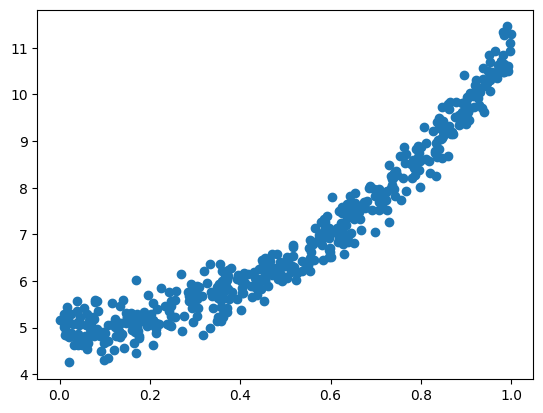

In [3]:
plt.scatter(data['t'],data['y'])
plt.show()

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   t       500 non-null    float64
 1   y       500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [5]:
x = np.array(data[['t']])
y = np.array(data[['y']])

#no se necesita preprocesar los datos, el método de ajusta a los datos, q pro los arboles de decision, el problema es el sobreajuste
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.5)

In [6]:
regressor = DecisionTreeRegressor()
regressor.fit(x_train,y_train)

DecisionTreeRegressor()

In [7]:
y_pred = regressor.predict(x_test) 
mse = mean_squared_error(y_test,y_pred)
mse

0.17215098503959658

In [8]:
regressor_p = DecisionTreeRegressor(max_depth = 3, 
                                    min_samples_split = 10,
                                    min_samples_leaf = 3)

regressor_p.fit(x_test,y_test)

DecisionTreeRegressor(max_depth=3, min_samples_leaf=3, min_samples_split=10)

In [9]:
y_pred_p = regressor_p.predict(x_test)
mse = mean_squared_error(y_test,y_pred_p)
mse

0.0970132283977656

In [10]:
from sklearn.tree import plot_tree

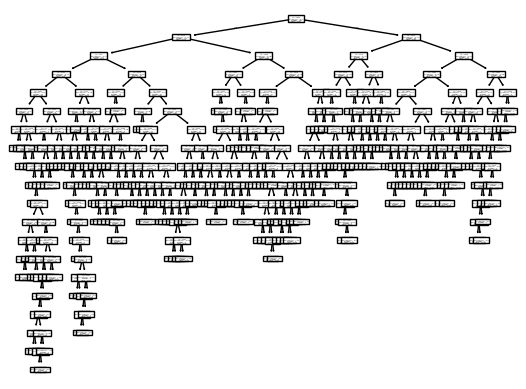

In [11]:
plot = plot_tree(decision_tree = regressor,
                feature_names = ['t'])

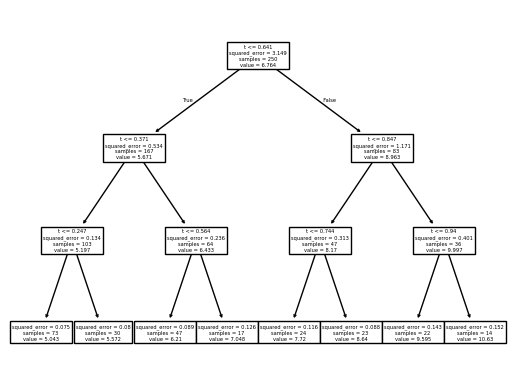

In [12]:
plot = plot_tree(decision_tree = regressor_p,
                feature_names = ['t'])

In [13]:
regressor_a = DecisionTreeRegressor(ccp_alpha = 0.01)
regressor_a.fit(x_train,y_train)

DecisionTreeRegressor(ccp_alpha=0.01)

In [14]:
y_pred_a = regressor_a.predict(x_test)
mse = mean_squared_error(y_test,y_pred_a)
mse

0.13868741330944506

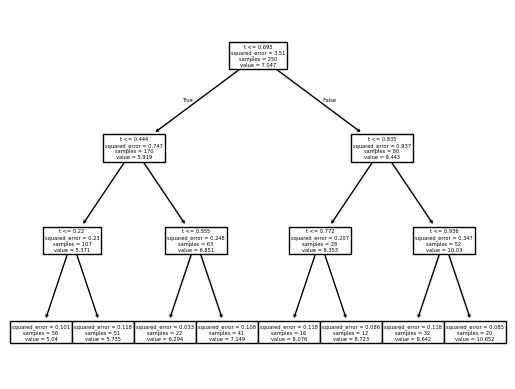

In [15]:
plot = plot_tree(decision_tree = regressor_a,
                feature_names = ['t'])

In [16]:
path = regressor_a.cost_complexity_pruning_path(x_train, y_train)

In [17]:
ccp_alphas = path.ccp_alphas

In [18]:
Alpha = []
MSE = []
for alpha in ccp_alphas:
    reg = DecisionTreeRegressor(ccp_alpha = alpha)
    reg.fit(x_train, y_train)
    mse = mean_squared_error(y_test,reg.predict(x_test))
    #print(f"ccp_alpha = {alpha:.10f}, mse = {mean_squared_error(y_test,reg.predict(x_test)):.10f}")
    Alpha.append(alpha)
    MSE.append(mse)

mse_o = np.argmin(MSE)
print("El valor optimo de alpha es: ", Alpha[mse_o])

El valor optimo de alpha es:  0.0021700953793375114


In [19]:
regressor_b = DecisionTreeRegressor(ccp_alpha = 0.00240399526101325)
regressor_b.fit(x_train,y_train)

DecisionTreeRegressor(ccp_alpha=0.00240399526101325)

In [20]:
y_pred_b = regressor_b.predict(x_test)
mse = mean_squared_error(y_test,y_pred_b)
mse

0.11793106876360752

<function matplotlib.pyplot.show(close=None, block=None)>

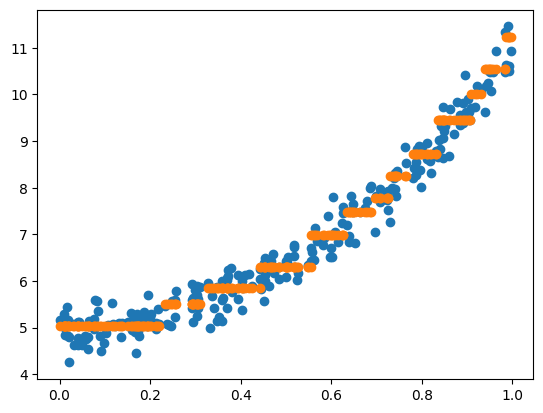

In [21]:
plt.scatter(x_test,y_test)
plt.scatter(x_test, y_pred_b)
plt.show

## DecisionTreeClassifier

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

In [27]:
data = pd.read_csv('Datasets/usuarios.csv')
data.head(5)

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB


In [29]:
data['clase'].value_counts()

clase
0    86
2    44
1    40
Name: count, dtype: int64

In [32]:
x = [x for x in data.columns if x != 'clase']
x = np.array(data[x])
y = np.array(data['clase'])

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42)

In [31]:
clf = DecisionTreeClassifier()

In [34]:
clf.fit(x_train,y_train)

DecisionTreeClassifier()

In [36]:
y_pred = clf.predict(x_test)
y_pred 

array([0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 2,
       1, 0, 2, 2, 0, 1, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 2, 0, 2, 0, 0, 0])

In [41]:
from sklearn.metrics import classification_report

In [42]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.66      0.92      0.77        25
           1       0.86      0.40      0.55        15
           2       0.89      0.73      0.80        11

    accuracy                           0.73        51
   macro avg       0.80      0.68      0.70        51
weighted avg       0.77      0.73      0.71        51



In [44]:
lista = [x for x in data.columns if x != 'clase']

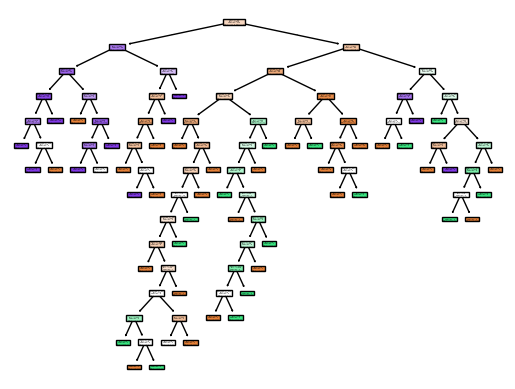

In [56]:
plot = plot_tree(decision_tree = clf,
                 feature_names = lista,
                 filled = True)

In [49]:
clf.get_depth()

14

In [50]:
clf.get_n_leaves()

np.int64(51)

In [84]:
param_grid = {'ccp_alpha':np.linspace(0,0.5,100)}
grid = GridSearchCV(estimator = DecisionTreeClassifier(criterion = 'entropy'),
                    param_grid = param_grid,
                    scoring = 'accuracy',
                    cv = 5,
                   return_)

In [85]:
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(criterion='entropy'),
             param_grid={'ccp_alpha': array([0.        , 0.00505051, 0.01010101, 0.01515152, 0.02020202,
       0.02525253, 0.03030303, 0.03535354, 0.04040404, 0.04545455,
       0.05050505, 0.05555556, 0.06060606, 0.06565657, 0.07070707,
       0.07575758, 0.08080808, 0.08585859, 0.09090909, 0.0959596 ,
       0.1010101 , 0.10606061, 0.11111111, 0.11...
       0.32828283, 0.33333333, 0.33838384, 0.34343434, 0.34848485,
       0.35353535, 0.35858586, 0.36363636, 0.36868687, 0.37373737,
       0.37878788, 0.38383838, 0.38888889, 0.39393939, 0.3989899 ,
       0.4040404 , 0.40909091, 0.41414141, 0.41919192, 0.42424242,
       0.42929293, 0.43434343, 0.43939394, 0.44444444, 0.44949495,
       0.45454545, 0.45959596, 0.46464646, 0.46969697, 0.47474747,
       0.47979798, 0.48484848, 0.48989899, 0.49494949, 0.5       ])},
             scoring='accuracy')

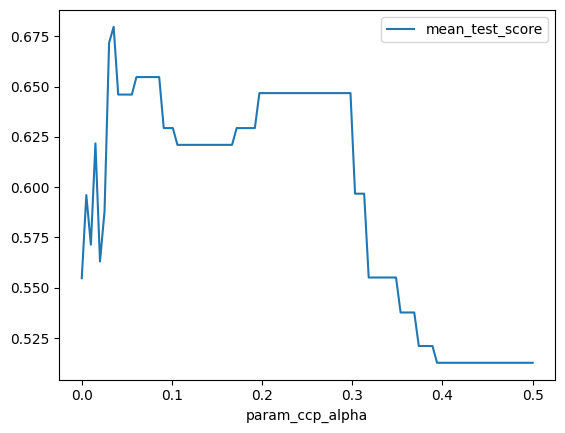

In [86]:

score = pd.DataFrame(grid.cv_results_)
score.plot(x = 'param_ccp_alpha', y = 'mean_test_score')
plt.show()

In [87]:
score.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_ccp_alpha', 'params', 'split0_test_score', 'split1_test_score',
       'split2_test_score', 'split3_test_score', 'split4_test_score',
       'mean_test_score', 'std_test_score', 'rank_test_score'],
      dtype='object')

In [88]:
score.head(2)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002172,0.000184,0.001793,0.000038,0.000000,{'ccp_alpha': 0.0},0.583333,0.500000,0.666667,0.458333,0.565217,0.554710,0.071757,70
1,0.002152,0.000110,0.001566,0.000079,0.005051,{'ccp_alpha': 0.005050505050505051},0.583333,0.666667,0.708333,0.500000,0.521739,0.596014,0.080627,59


In [89]:
importancia = pd.DataFrame({'predictor': lista,
                            'importancia': clf.feature_importances_})

In [90]:
importancia.sort_values('importancia', ascending = True)

,predictor,importancia
1,paginas,0.066360
0,duracion,0.246617
2,acciones,0.298398
3,valor,0.388624


In [91]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [92]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[23,  1,  1],
       [ 9,  6,  0],
       [ 3,  0,  8]])

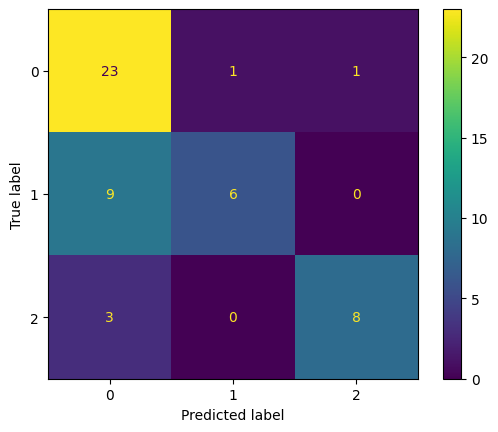

In [93]:
ds = ConfusionMatrixDisplay(cm)
ds.plot()

In [94]:
grid.best_estimator_

DecisionTreeClassifier(ccp_alpha=np.float64(0.03535353535353536),
                       criterion='entropy')

In [95]:
grid.best_params_

{'ccp_alpha': np.float64(0.03535353535353536)}

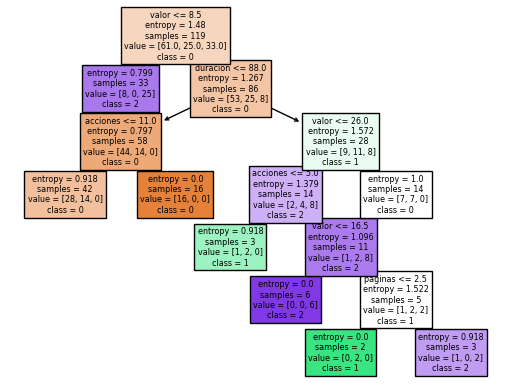

In [99]:
                        plot = plot_tree(decision_tree = grid.best_estimator_,
                                         feature_names = lista,
                                         class_names = ['0', '1', '2'],
                                         filled = True)